In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [3]:
transform = transforms.ToTensor()

train_ds = datasets.MNIST(root='../data', train=True,  download=True, transform=transform)
test_ds  = datasets.MNIST(root='../data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=1000)

print(f"训练样本: {len(train_ds)}, 测试样本: {len(test_ds)}")

100.0%
100.0%
100.0%
100.0%

训练样本: 60000, 测试样本: 10000


In [4]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 128)   # 输入层(784) → 隐藏层(128)
        self.fc2 = nn.Linear(128, 10)      # 隐藏层(128) → 输出层(10类)

    def forward(self, x):
        x = x.view(-1, 28*28)              # 把 28x28 图片展平成一维
        x = torch.relu(self.fc1(x))        # 隐藏层 + ReLU 激活
        return self.fc2(x)                 # 输出层（softmax 交给损失函数）

model = MLP()
print(model)   # 打印模型结构

MLP(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [5]:
images, labels = next(iter(train_loader))
print("输入图像形状:", images.shape)      # 应为 torch.Size([64, 1, 28, 28])
print("标签形状:", labels.shape)          # 应为 torch.Size([64])

out = model(images)
print("模型输出形状:", out.shape)         # 应为 torch.Size([64, 10])

输入图像形状: torch.Size([64, 1, 28, 28])
标签形状: torch.Size([64])
模型输出形状: torch.Size([64, 10])


In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
print("训练就绪！")

训练就绪！


In [7]:
def train_one_epoch():
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        optimizer.zero_grad()              # ① 清空梯度
        outputs = model(images)            # ② 前向传播
        loss = criterion(outputs, labels)  # ③ 计算损失
        loss.backward()                    # ④ 反向传播（自动求导！）
        optimizer.step()                   # ⑤ 更新权重
        total_loss += loss.item()
    return total_loss / len(train_loader)

loss_history = []
for epoch in range(5):
    avg_loss = train_one_epoch()
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1}: 平均损失 = {avg_loss:.4f}")

Epoch 1: 平均损失 = 0.4400
Epoch 2: 平均损失 = 0.2253
Epoch 3: 平均损失 = 0.1714
Epoch 4: 平均损失 = 0.1378
Epoch 5: 平均损失 = 0.1151


In [8]:
def evaluate():
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

acc = evaluate()
print(f"测试集准确率: {acc*100:.2f}%")

测试集准确率: 96.77%


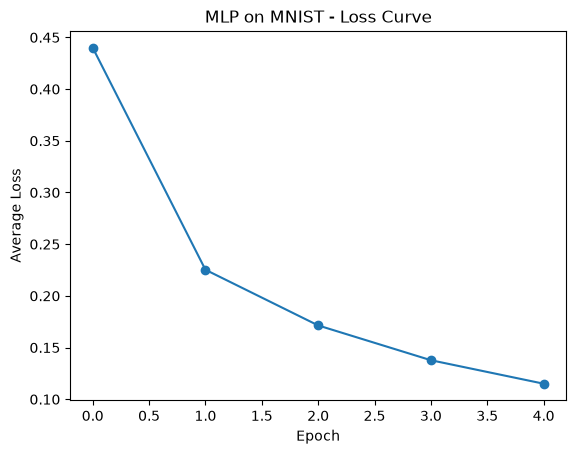

In [9]:
plt.plot(loss_history, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("MLP on MNIST - Loss Curve")
plt.show()